# SC-HMM Phase 3 — Spectral-Clustering HMM with Macro Overlay

**Strategy:** Spectral Clustering identifies market regimes (bull / neutral / bear) from price-return features. A macro confirmation layer (VIX, HY OAS, yield curve) disambiguates spectral bear signals — distinguishing genuine crashes from high-volatility recoveries.

**Asset universe:** SPY · IWM · IEF · TIP · GLD  
**Macro signals:** VIXCLS · T10Y2Y · BAMLH0A0HYM2 (FRED)  
**Train / Test split:** ≤ 2018-12-31 (in-sample) / ≥ 2019-01-01 (out-of-sample)  


In [ ]:
# ── Cell 1: Imports & Settings ───────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import Counter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Asset universe ────────────────────────────────────────────────────────
ASSETS    = ['SPY', 'IWM', 'IEF', 'TIP', 'GLD']
N_ASSETS  = len(ASSETS)

# ── Spectral / backtest parameters ───────────────────────────────────────
K_MIN               = 2
K_MAX               = 3
K_NN                = 7
MAX_SPECTRAL_WINDOW = 260
INITIAL_WINDOW      = 156
REFIT_CADENCE       = 4
SMOOTH_WINDOW       = 3
TC                  = 0.001
WINDOWS             = [13, 26]   # quarter (13w) and half-year (26w) rolling windows
N_INIT_KMEANS       = 20
ANNUALISE           = 52
P_SIZE              = 3

# ── Train / test split ───────────────────────────────────────────────────
TRAIN_END  = '2018-12-31'
TEST_START = '2019-01-01'
DATA_START = '2002-01-01'
DATA_END   = '2026-04-03'

# ── Regime labels ────────────────────────────────────────────────────────
ALL_REGIMES   = ['bull', 'neutral', 'bear']
REGIME_COLORS = {'bull': '#2ecc71', 'neutral': '#f39c12', 'bear': '#e74c3c'}
REGIME_TO_ID  = {'bull': 0, 'neutral': 1, 'bear': 2}
ID_TO_REGIME  = {0: 'bull', 1: 'neutral', 2: 'bear'}

# ── Macro overlay thresholds ─────────────────────────────────────────────
MACRO_BEAR_THRESH    = 1.0   # composite score above which bear is confirmed
MACRO_NEUTRAL_THRESH = 0.5   # composite score below -0.5 → downgrade bear to neutral
MACRO_EXTREME_THRESH = 2.0   # VIX z-score above which neutral is upgraded to bear

# ── Regime labeling: Sharpe-adjusted equity score ────────────────────────
# score(k) = mean(SPY, IWM) × 52 − LABEL_VOL_ALPHA × vol(SPY) × √52
# Penalises high-volatility clusters so the high-vol recovery cluster
# (e.g. 2009, 2020 V-shapes) stays labelled 'bear' despite positive mean returns.
LABEL_VOL_ALPHA = 0.5

# ── Macro data path ──────────────────────────────────────────────────────
MACRO_PATH = 'macro_data.csv' 

print('SC-HMM Phase 3 | Spectral Clustering + Macro Overlay')
print(f'Assets        : {ASSETS}')
print(f'Macro vars    : VIX, T10Y2Y, BAMLH0A0HYM2')
print(f'Train ≤ {TRAIN_END}  |  Test ≥ {TEST_START}')
print(f'Corr windows  : {WINDOWS}')
print(f'Label alpha   : {LABEL_VOL_ALPHA}')
print(f'Macro thresholds: bear_confirm={MACRO_BEAR_THRESH}, downgrade={MACRO_NEUTRAL_THRESH}, extreme_upgrade={MACRO_EXTREME_THRESH}')


SC-HMM Phase 3 | Spectral Clustering + Macro Overlay
Assets        : ['SPY', 'IWM', 'IEF', 'TIP', 'GLD']
Macro vars    : VIX, T10Y2Y, BAMLH0A0HYM2
Train ≤ 2018-12-31  |  Test ≥ 2019-01-01
Corr windows  : [13, 26]
Label alpha   : 0.5
Macro thresholds: bear_confirm=1.0, downgrade=0.5, extreme_upgrade=2.0


In [ ]:
# ── Cell 2: Data Load ────────────────────────────────────────────────────
# Asset prices: yfinance daily → resampled to weekly Friday-close.
# Macro data  : FRED CSV (VIX, T10Y2Y, BAMLH0A0HYM2), weekly.

print(f'yfinance {yf.__version__}')

def fetch_weekly_prices(tickers, start, end):
    frames = {}
    for ticker in tickers:
        raw = yf.download(
            tickers=ticker, start=start, end=end,
            interval='1d', auto_adjust=True, progress=False,
        )
        if raw.empty:
            print(f'  WARNING: No data for {ticker}')
            continue
        close  = raw['Close'].iloc[:, 0] if isinstance(raw.columns, pd.MultiIndex) else raw['Close']
        weekly = close.resample('W-FRI').last().dropna()
        frames[ticker] = weekly
        print(f'  {ticker}: {len(weekly)} obs | {weekly.index[0].date()} to {weekly.index[-1].date()}')
    return pd.DataFrame(frames)

prices_raw = fetch_weekly_prices(ASSETS, start=DATA_START, end=DATA_END).sort_index()
prices_raw = prices_raw[[a for a in ASSETS if a in prices_raw.columns]]
prices     = prices_raw.dropna()   # GLD start date (~Nov 2004) is the binding constraint
assert len(prices) > 0, 'prices empty'

ret    = prices.pct_change().dropna()
assets = ret.columns.tolist()

macro_raw = pd.read_csv(MACRO_PATH, parse_dates=['observation_date'], index_col='observation_date')
macro_raw = macro_raw.resample('W-FRI').last().ffill()

macro       = macro_raw.reindex(ret.index, method='ffill')
first_valid = macro.dropna().index[0]
macro       = macro.loc[first_valid:]
ret         = ret.loc[first_valid:]
prices      = prices.loc[first_valid:]

assert macro.isna().sum().sum() == 0, f'Macro NaNs remain: {macro.isna().sum()}'

N_OBS = len(ret)
print(f'\nPrice table    : {prices.index[0].date()} to {prices.index[-1].date()} | {len(prices)} weeks')
print(f'Returns        : {ret.index[0].date()} to {ret.index[-1].date()} | N={N_OBS}')
print(f'Backtest start : {ret.index[INITIAL_WINDOW + 1].date()}')
print(f'Macro          : {macro.index[0].date()} to {macro.index[-1].date()} | {len(macro)} obs')
print(macro.describe().round(2))


yfinance 0.2.66
  SPY: 1266 obs | 2002-01-04 to 2026-04-03
  IWM: 1266 obs | 2002-01-04 to 2026-04-03
  IEF: 1236 obs | 2002-08-02 to 2026-04-03
  TIP: 1166 obs | 2003-12-05 to 2026-04-03
  GLD: 1116 obs | 2004-11-19 to 2026-04-03

Price table    : 2004-11-26 to 2026-04-03 | 1115 weeks
Returns        : 2004-11-26 to 2026-04-03 | N=1115
Backtest start : 2007-11-30
Macro          : 2004-11-26 to 2026-04-03 | 1115 obs
        VIXCLS   T10Y2Y  BAMLH0A0HYM2   T10YIE
count  1115.00  1115.00       1115.00  1115.00
mean     18.97     0.97          5.00     2.10
std       8.61     0.94          2.62     0.40
min       9.14    -1.06          2.41     0.12
25%      13.28     0.20          3.47     1.85
50%      16.50     0.86          4.25     2.21
75%      21.89     1.67          5.72     2.36
max      79.13     2.91         21.30     2.95


In [45]:
# ── Cell 3: Utility Functions ─────────────────────────────────────────────

def rolling_corr_safe(df_win, min_obs=13):
    """Pairwise correlation with a minimum-observation guard.
    Returns zero vector and True (flagged) if the window is too short.
    """
    m     = df_win.shape[1]
    pairs = [(i, j) for i in range(m) for j in range(i + 1, m)]
    if len(df_win) < min_obs:
        return np.zeros(len(pairs)), True
    try:
        C = df_win.corr().values
        if np.any(np.isnan(C)) or abs(np.linalg.det(C)) < 1e-10:
            return np.zeros(len(pairs)), True
        return np.array([C[i, j] for i, j in pairs]), False
    except Exception:
        return np.zeros(len(pairs)), True


def compute_metrics(returns, rf=0.0, freq=ANNUALISE):
    """Standard risk/return metrics for a weekly return series."""
    r = np.asarray(returns, dtype=float)
    n = len(r)
    if n < 2:
        return {k: 'N/A' for k in ['Cumul.Ret','CAGR','Ann.Vol','Sharpe','Sortino','Max DD','Calmar','Hit Rate']}
    wealth  = np.cumprod(1 + r)
    years   = n / freq
    total   = wealth[-1] - 1
    cagr    = wealth[-1] ** (1 / years) - 1
    vol     = r.std(ddof=1) * np.sqrt(freq)
    excess  = r.mean() * freq - rf
    sharpe  = excess / vol if vol > 0 else np.nan
    dn      = r[r < 0]
    dn_vol  = dn.std(ddof=1) * np.sqrt(freq) if len(dn) > 1 else np.nan
    sortino = excess / dn_vol if (dn_vol and dn_vol > 0) else np.nan
    peak    = np.maximum.accumulate(wealth)
    dd      = wealth / peak - 1
    max_dd  = dd.min()
    calmar  = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return {
        'Cumul.Ret': f'{total:.1%}', 'CAGR': f'{cagr:.2%}',
        'Ann.Vol':   f'{vol:.2%}',   'Sharpe':   f'{sharpe:.2f}',
        'Sortino':   f'{sortino:.2f}', 'Max DD': f'{max_dd:.2%}',
        'Calmar':    f'{calmar:.2f}', 'Hit Rate': f'{np.mean(r > 0):.1%}',
    }


def rolling_sharpe(r, window=52):
    s = pd.Series(r)
    return (s.rolling(window).mean() * ANNUALISE /
            (s.rolling(window).std(ddof=1) * np.sqrt(ANNUALISE))).values

def cum_ret(r):        return np.cumprod(1 + np.asarray(r)) - 1
def drawdown_series(r):
    w = np.cumprod(1 + np.asarray(r))
    return w / np.maximum.accumulate(w) - 1

print('Utility functions defined.')


Utility functions defined.


In [ ]:
# ── Cell 4: Feature Construction ─────────────────────────────────────────
# Feature matrix X (57 features per observation), strictly causal.
# Macro data is NOT included in the spectral graph; it enters only in Cell 8.
#
# Feature breakdown (windows = [13w, 26w]):
#   Rolling mean + std    : 5 assets × 2 windows            = 20
#   Current return + |Δ|  : 5 assets × 2                    = 10
#   SPY momentum          : 13w mean, 26w mean, 13w vol      =  3
#   TIP momentum          : 13w mean, 13w vol                =  2
#   IEF momentum          : 13w mean, 13w vol                =  2
#   Excess returns        : (SPY−IEF) 13w+26w, (IWM−IEF) 13w+26w = 4
#   Size factor           : IWM−SPY 13w+26w                 =  2
#   Volatility ratios     : SPY vol / IEF vol 13w+26w        =  2
#                                                      Total = 57
#
# TIP is excluded from pairwise correlations because IEF/TIP ≈ 0.97,
# making the pair nearly redundant and adding near-zero-variance noise.

CORR_ASSETS_SC = [a for a in ASSETS if a != 'TIP']

def build_features(ret_df, windows=WINDOWS):
    """Construct 57-feature matrix X. All features are strictly causal."""
    m          = ret_df.shape[1]
    n          = len(ret_df)
    all_rows   = []
    flag_count = 0

    spy_i    = ret_df.columns.get_loc('SPY')
    tip_i    = ret_df.columns.get_loc('TIP')
    ief_i    = ret_df.columns.get_loc('IEF')
    iwm_i    = ret_df.columns.get_loc('IWM')
    corr_idx = [ret_df.columns.get_loc(a) for a in CORR_ASSETS_SC]

    w_short = windows[0]   # 13 weeks
    w_long  = windows[1]   # 26 weeks

    for t in range(n):
        row = []

        # Rolling mean & std: all 5 assets, 2 windows (20 features)
        for l in windows:
            win = ret_df.iloc[max(0, t - l + 1): t + 1]
            row.extend(win.mean().values)
            row.extend(win.std(ddof=0).fillna(0).values)

        # Pairwise correlations: 4 assets (TIP excluded), 2 windows (12 features)
        for l in windows:
            win_corr  = ret_df.iloc[max(0, t - l + 1): t + 1].iloc[:, corr_idx]
            cv, flagged = rolling_corr_safe(win_corr)
            flag_count += flagged
            row.extend(cv)

        # Current return and abs 1-period change (10 features)
        row.extend(ret_df.iloc[t].values)
        row.extend(
            np.abs(ret_df.iloc[t].values - ret_df.iloc[t - 1].values)
            if t > 0 else np.zeros(m)
        )

        # SPY momentum (3 features)
        spy_short = ret_df.iloc[max(0, t - w_short + 1): t + 1].iloc[:, spy_i].values
        spy_long  = ret_df.iloc[max(0, t - w_long  + 1): t + 1].iloc[:, spy_i].values
        row.extend([spy_short.mean(), spy_long.mean(), spy_short.std(ddof=0)])

        # TIP momentum (2 features)
        tip_short = ret_df.iloc[max(0, t - w_short + 1): t + 1].iloc[:, tip_i].values
        row.extend([tip_short.mean(), tip_short.std(ddof=0)])

        # IEF momentum (2 features)
        ief_short = ret_df.iloc[max(0, t - w_short + 1): t + 1].iloc[:, ief_i].values
        row.extend([ief_short.mean(), ief_short.std(ddof=0)])

        # Excess returns: SPY−IEF and IWM−IEF, 13w + 26w (4 features)
        iwm_short = ret_df.iloc[max(0, t - w_short + 1): t + 1].iloc[:, iwm_i].values
        iwm_long  = ret_df.iloc[max(0, t - w_long  + 1): t + 1].iloc[:, iwm_i].values
        ief_long  = ret_df.iloc[max(0, t - w_long  + 1): t + 1].iloc[:, ief_i].values
        row.extend([
            spy_short.mean() - ief_short.mean(),
            spy_long.mean()  - ief_long.mean(),
            iwm_short.mean() - ief_short.mean(),
            iwm_long.mean()  - ief_long.mean(),
        ])

        # Size factor: IWM − SPY, 13w + 26w (2 features)
        row.extend([
            iwm_short.mean() - spy_short.mean(),
            iwm_long.mean()  - spy_long.mean(),
        ])

        # Volatility ratio: SPY vol / IEF vol, 13w + 26w (2 features)
        spy_vol_s = spy_short.std(ddof=0) + 1e-10
        ief_vol_s = ief_short.std(ddof=0) + 1e-10
        spy_vol_l = spy_long.std(ddof=0)  + 1e-10
        ief_vol_l = ief_long.std(ddof=0)  + 1e-10
        row.extend([spy_vol_s / ief_vol_s, spy_vol_l / ief_vol_l])

        all_rows.append(row)

    X = np.nan_to_num(np.array(all_rows, dtype=float))
    print(f'Features: {X.shape[1]} per obs × {X.shape[0]} obs | corr flags: {flag_count}')
    if flag_count > 50:
        print(f'  WARNING: {flag_count} corr flags — check WINDOWS vs min_obs')
    else:
        print(f'  OK: corr flags near-zero (expected with WINDOWS={WINDOWS})')
    return X

print(f'Correlation assets (TIP excluded): {CORR_ASSETS_SC}')
print('Building feature matrix...')
X_full = build_features(ret)
print('Feature matrix ready.')


Correlation assets (TIP excluded): ['SPY', 'IWM', 'IEF', 'GLD']
Building feature matrix...
Features: 57 per obs × 1115 obs | corr flags: 24
  OK: corr flags near-zero (expected with WINDOWS=[13, 26])
Feature matrix ready.


In [47]:
# ── Cell 5: Spectral Clustering Core ─────────────────────────────────────
# Self-tuning affinity matrix following Zelnik-Manor & Perona (2004):
# each point's local bandwidth σ_i = distance to its K-th nearest neighbour.
# This adapts to local density, avoiding the pitfall of a single global σ.

def self_tuning_sigma(X, k=K_NN):
    n = X.shape[0]
    k = max(1, min(k, n - 1))
    D = cdist(X, X, metric='euclidean')
    np.fill_diagonal(D, np.inf)
    return np.maximum(np.sort(D, axis=1)[:, k - 1], 1e-10)


def build_W(X, k=K_NN):
    """Self-tuning affinity matrix (Zelnik-Manor & Perona 2004).
    Falls back to a global sigma if the self-tuning matrix is degenerate.
    """
    n     = X.shape[0]
    D2    = cdist(X, X, metric='sqeuclidean')
    sigma = self_tuning_sigma(X, k=k)
    W     = np.exp(-D2 / np.maximum(2 * np.outer(sigma, sigma), 1e-30))
    np.fill_diagonal(W, 0)
    off = W[~np.eye(n, dtype=bool)]
    if W.sum(axis=1).min() < 1e-6 or np.median(off) < 1e-6:
        gs = np.median(np.sqrt(D2[D2 > 0])) / np.sqrt(2)
        W  = np.exp(-D2 / (2 * max(gs, 1e-10) ** 2))
        np.fill_diagonal(W, 0)
        return W, 'global-fallback'
    return W, 'self-tuning'


def laplacian_eigenvectors(W, n_vecs):
    """Normalised symmetric graph Laplacian eigenvectors."""
    d       = np.maximum(W.sum(axis=1), 1e-10)
    D_isqrt = np.diag(1.0 / np.sqrt(d))
    L       = np.eye(len(W)) - D_isqrt @ W @ D_isqrt
    L       = (L + L.T) / 2.0
    vals, vecs = np.linalg.eigh(L)
    idx     = np.argsort(vals)
    return vecs[:, idx][:, :n_vecs], vals[idx]


def select_k_eigengap(eigenvalues, k_min=K_MIN, k_max=K_MAX):
    """Local-scale normalised eigengap criterion for selecting K."""
    n_eigs     = len(eigenvalues)
    k_hi       = min(k_max, n_eigs - 2)
    k_lo       = min(k_min, k_hi)
    raw_gaps   = np.array([eigenvalues[k] - eigenvalues[k - 1]
                            for k in range(k_lo, k_hi + 1)])
    local_mean = np.array([
        np.mean(eigenvalues[max(0, k - 1): min(n_eigs, k + 3)])
        for k in range(k_lo, k_hi + 1)
    ])
    norm_gaps = raw_gaps / np.maximum(local_mean, 1e-10)
    k_star    = k_lo + int(np.argmax(norm_gaps))
    return k_star, raw_gaps


def run_kmeans(U, K):
    return KMeans(n_clusters=K, n_init=N_INIT_KMEANS,
                  random_state=RANDOM_STATE).fit_predict(U)

print('Spectral clustering core defined.')
print(f'  K_NN={K_NN} | K range: [{K_MIN}, {K_MAX}] | Kernel: self-tuning Gaussian')


Spectral clustering core defined.
  K_NN=7 | K range: [2, 3] | Kernel: self-tuning Gaussian


In [48]:
# ── Cell 6: Parameter Estimation & Regime Mapping ────────────────────────
# map_regimes assigns economic labels (bull / neutral / bear) to spectral clusters.
#
# Primary criterion — Sharpe-adjusted equity score:
#   score(k) = mean(SPY, IWM) × 52 − LABEL_VOL_ALPHA × vol(SPY) × √52
#
# Without the vol penalty, the high-vol recovery cluster (2009, 2020)
# can have a positive mean return exceeding the neutral cluster, producing
# an incoherent label ordering (neutral > bull). The vol penalty corrects this.
#
# Fallback 1: if score spread < 1% ann → sort by vol (highest → bear).
# Fallback 2: if vol spread  < 2% ann  → sort by TIP return (highest → bear).

def estimate_params(ret_df, labels, K):
    """Per-cluster mean, std, covariance, and count."""
    params = {}
    for k in range(K):
        idx = np.where(labels == k)[0]
        if len(idx) < 2:
            m = ret_df.shape[1]
            params[k] = {'mean': np.zeros(m), 'std': np.ones(m) * 1e-6,
                         'cov': np.eye(m), 'count': 0}
        else:
            arr = ret_df.iloc[idx].values
            params[k] = {'mean': arr.mean(0), 'std': arr.std(0, ddof=1),
                         'cov': np.cov(arr.T), 'count': len(idx)}
    return params


def transition_matrix(regime_id_seq, K_full=P_SIZE):
    """Empirical transition matrix from the observed regime-id sequence."""
    seq = np.asarray(regime_id_seq, dtype=int)
    P   = np.zeros((K_full, K_full))
    for a, b in zip(seq[:-1], seq[1:]):
        if 0 <= a < K_full and 0 <= b < K_full:
            P[a, b] += 1
    rs = P.sum(1, keepdims=True)
    P[rs.squeeze() == 0] = 1.0 / K_full
    return P / P.sum(1, keepdims=True)


def map_regimes(params, asset_list, K, vol_alpha=LABEL_VOL_ALPHA):
    """Map spectral cluster indices to (bull / neutral / bear) labels."""
    si = asset_list.index('SPY')
    wi = asset_list.index('IWM')
    bi = asset_list.index('TIP')

    labels_by_K = {2: ['bear', 'bull'], 3: ['bear', 'neutral', 'bull']}
    label_list  = labels_by_K.get(K, ['bear', 'neutral', 'bull'])

    def assign(sk):
        return {sk[i]: label_list[i] for i in range(K)}

    # Primary: Sharpe-adjusted equity score
    scores = {}
    for k in range(K):
        eq_mean  = (params[k]['mean'][si] + params[k]['mean'][wi]) / 2
        spy_vol  = params[k]['std'][si]
        scores[k] = eq_mean * ANNUALISE - vol_alpha * spy_vol * np.sqrt(ANNUALISE)

    score_spread = max(abs(scores[i] - scores[j])
                       for i in range(K) for j in range(i + 1, K))
    if score_spread >= 0.01:
        return assign(sorted(range(K), key=lambda k: scores[k])), 'primary-sharpe'

    # Fallback 1: sort by equity volatility
    vols       = {k: params[k]['std'][[si, wi]].mean() * np.sqrt(ANNUALISE) for k in range(K)}
    vol_spread = max(abs(vols[i] - vols[j]) for i in range(K) for j in range(i + 1, K))
    if vol_spread >= 0.02:
        return assign(sorted(range(K), key=lambda k: vols[k], reverse=True)), 'tiebreak-vol'

    # Fallback 2: sort by TIP return (flight-to-quality proxy)
    bond_r = {k: params[k]['mean'][bi] for k in range(K)}
    return assign(sorted(range(K), key=lambda k: bond_r[k], reverse=True)), 'tiebreak-bond'

print('Parameter estimation and regime mapping defined.')
print(f'  Sharpe-adjusted labeling | vol_alpha = {LABEL_VOL_ALPHA}')


Parameter estimation and regime mapping defined.
  Sharpe-adjusted labeling | vol_alpha = 0.5


In [49]:
# ── Cell 7: Allocation Table ──────────────────────────────────────────────
#           SPY    IWM    IEF    TIP    GLD
ALLOC = {
    'bull':    np.array([0.60, 0.20, 0.05, 0.05, 0.10]),
    'neutral': np.array([0.30, 0.10, 0.20, 0.15, 0.25]),
    'bear':    np.array([0.05, 0.00, 0.30, 0.25, 0.40]),
}
for reg, w in ALLOC.items():
    assert abs(w.sum() - 1.0) < 1e-9

print('Allocation table (SPY | IWM | IEF | TIP | GLD):')
print(f'  {"Regime":10} {"SPY":>6} {"IWM":>6} {"IEF":>6} {"TIP":>6} {"GLD":>6}')
for reg, w in ALLOC.items():
    print(f'  {reg:10} {w[0]:>6.0%} {w[1]:>6.0%} {w[2]:>6.0%} {w[3]:>6.0%} {w[4]:>6.0%}')


Allocation table (SPY | IWM | IEF | TIP | GLD):
  Regime        SPY    IWM    IEF    TIP    GLD
  bull          60%    20%     5%     5%    10%
  neutral       30%    10%    20%    15%    25%
  bear           5%     0%    30%    25%    40%


In [50]:
# ── Cell 8: Macro Overlay ────────────────────────────────────────────────
# The spectral model clusters by volatility structure, not return direction.
# This means 'bear' contains two economically distinct sub-states:
#   (a) Genuine crash / macro deterioration  → stay fully defensive
#   (b) High-vol recovery (2009, mid-2020)   → ease back toward neutral
#
# The macro overlay is a bear-state disambiguator using a composite z-score:
#   composite = ( z(VIX) + z(HY OAS) + z(−T10Y2Y) ) / 3
#
# Overlay logic:
#   IF spectral = 'bear':
#       composite < −MACRO_NEUTRAL_THRESH  → DOWNGRADE to neutral (recovery)
#       else                               → CONFIRM bear (genuine stress)
#   IF spectral = 'neutral':
#       VIX z > MACRO_EXTREME_THRESH       → UPGRADE to bear (panic onset)
#       else                               → KEEP neutral
#   IF spectral = 'bull':
#       no change (bull is never overridden)
#
# All z-scores use a causal 104-week rolling window.

MACRO_ZSCORE_WINDOW = 104

def compute_macro_score(macro_df, window=MACRO_ZSCORE_WINDOW):
    """Composite macro stress score and VIX z-score. Strictly causal."""
    vix  = macro_df['VIXCLS']
    hy   = macro_df['BAMLH0A0HYM2']
    t10y = macro_df['T10Y2Y']

    def rolling_zscore(s, w):
        mu  = s.rolling(w, min_periods=w // 2).mean()
        std = s.rolling(w, min_periods=w // 2).std(ddof=1).replace(0, np.nan)
        return ((s - mu) / std).fillna(0)

    z_vix  = rolling_zscore(vix,   window)
    z_hy   = rolling_zscore(hy,    window)
    z_t10y = rolling_zscore(-t10y, window)   # inverted: higher = more inverted yield curve

    composite = (z_vix + z_hy + z_t10y) / 3.0
    return composite, z_vix


macro_score_full, vix_z_full = compute_macro_score(macro)

# Sanity check on key historical episodes
episodes = {
    'GFC peak (2008-10)':       '2008-10-10',
    'Recovery (2009-06)':       '2009-06-05',
    'COVID crash (2020-03)':    '2020-03-20',
    'COVID recovery (2020-06)': '2020-06-05',
    'Rate hike bear (2022-06)': '2022-06-10',
    'Bull 2017 mid':            '2017-06-09',
    'Bull 2024 mid':            '2024-06-07',
}
print('Macro score sanity check (high = stressed, low = benign):')
print(f'  {"Episode":35s}  {"Composite":>10}  {"VIX z":>8}  {"VIX level":>10}')
for name, date in episodes.items():
    try:
        idx   = macro_score_full.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
        score = macro_score_full.iloc[idx]
        vz    = vix_z_full.iloc[idx]
        vix_v = macro.iloc[idx]['VIXCLS']
        print(f'  {name:35s}  {score:>+10.2f}  {vz:>+8.2f}  {vix_v:>10.1f}')
    except Exception as e:
        print(f'  {name}: error ({e})')

print(f'\nDowngrade bear → neutral when composite score < −{MACRO_NEUTRAL_THRESH}')
print(f'Upgrade neutral → bear when VIX z-score > {MACRO_EXTREME_THRESH}')
print('Macro overlay defined. Ready for walk-forward backtest.')


Macro score sanity check (high = stressed, low = benign):
  Episode                               Composite     VIX z   VIX level
  GFC peak (2008-10)                        +2.67     +6.01        70.0
  Recovery (2009-06)                        -0.53     -0.11        29.6
  COVID crash (2020-03)                     +3.57     +6.10        66.0
  COVID recovery (2020-06)                  -0.84     +0.50        24.5
  Rate hike bear (2022-06)                  +1.17     +0.98        27.8
  Bull 2017 mid                             -0.40     -1.04        10.7
  Bull 2024 mid                             -0.98     -1.16        12.2

Downgrade bear → neutral when composite score < −0.5
Upgrade neutral → bear when VIX z-score > 2.0
Macro overlay defined. Ready for walk-forward backtest.


In [51]:
# ── Cell 9: Walk-Forward Backtest ────────────────────────────────────────
# Both strategies are produced in a single loop:
#   (A) SC-HMM  — spectral regime only, no overlay
#   (B) SC-HMM + Macro Overlay — spectral regime with macro confirmation
#
# The spectral model refits every REFIT_CADENCE steps on a rolling window
# of up to MAX_SPECTRAL_WINDOW observations. The transition matrix is
# updated from past regime history only — no future information leaks in.

print('=' * 66)
print('SC-HMM Phase 3 | Spectral + Macro Overlay Walk-Forward Backtest')
print('=' * 66)

n_total = len(ret)

store = {
    'dates': [],
    'r_hard': [], 'w_hard': [], 'pred_reg': [], 'cur_reg': [], 'to_hard': [],
    'r_overlay': [], 'w_overlay': [], 'to_overlay': [],
    'overlay_reg': [], 'overlay_action': [],
    'P_running': [], 'K_at_t': [], 'cur_K_labels': [], 'macro_score_t': [],
}

live_reg_ids     = []
current_reg      = 'neutral'
current_reg_id   = REGIME_TO_ID['neutral']
current_P        = np.ones((P_SIZE, P_SIZE)) / P_SIZE
last_w_hard      = ALLOC['neutral'].copy()
last_w_overlay   = ALLOC['neutral'].copy()
current_K        = 3
current_K_labels = ['bear', 'neutral', 'bull']
n_refits         = 0
refit_rule_cnt   = Counter()

for t in range(INITIAL_WINDOW, n_total - 1):

    # Refit spectral model every REFIT_CADENCE steps
    if (t - INITIAL_WINDOW) % REFIT_CADENCE == 0:
        n_sp    = min(t + 1, MAX_SPECTRAL_WINDOW)
        X_fit   = X_full[:t + 1][-n_sp:]
        ret_fit = ret.iloc[:t + 1].iloc[-n_sp:]

        X_sc = StandardScaler().fit_transform(X_fit)
        W_live, _ = build_W(X_sc, k=min(K_NN, n_sp - 1))
        U_live, eig_vals = laplacian_eigenvectors(W_live, n_vecs=K_MAX + 1)
        k_star, _ = select_k_eigengap(eig_vals, k_min=K_MIN, k_max=K_MAX)

        # Stability guard: fall back to K=2 if any cluster has < 8% of obs
        labels_live   = run_kmeans(U_live[:, :k_star], k_star)
        cluster_sizes = np.array([np.sum(labels_live == k) for k in range(k_star)])
        if cluster_sizes.min() / len(labels_live) < 0.08 and k_star > K_MIN:
            k_star      = K_MIN
            labels_live = run_kmeans(U_live[:, :k_star], k_star)

        params_live  = estimate_params(ret_fit, labels_live, k_star)
        lmap, rule   = map_regimes(params_live, assets, k_star)
        refit_rule_cnt[rule] += 1

        current_K        = k_star
        current_K_labels = [lmap[k] for k in range(k_star)]
        current_reg      = lmap[int(labels_live[-1])]
        current_reg_id   = REGIME_TO_ID[current_reg]
        n_refits        += 1

    # Update transition matrix from past regime history only
    if len(live_reg_ids) >= 2:
        current_P = transition_matrix(live_reg_ids, K_full=P_SIZE)

    # SC-HMM: allocate to the most likely next regime
    next_reg_id = int(np.argmax(current_P[current_reg_id]))
    pred_reg    = ID_TO_REGIME[next_reg_id]
    if pred_reg not in current_K_labels:
        pred_reg = current_reg
    w_h = ALLOC[pred_reg]

    # Macro overlay adjustment
    macro_t = macro_score_full.iloc[t]
    vix_z_t = vix_z_full.iloc[t]

    if pred_reg == 'bear':
        if macro_t < -MACRO_NEUTRAL_THRESH:
            overlay_reg, overlay_action = 'neutral', 'downgraded'
        else:
            overlay_reg, overlay_action = 'bear', 'confirmed'
    elif pred_reg == 'neutral' and vix_z_t > MACRO_EXTREME_THRESH:
        overlay_reg, overlay_action = 'bear', 'upgraded'
    else:
        overlay_reg, overlay_action = pred_reg, 'pass'

    w_ov = ALLOC[overlay_reg]

    # Realised return for next week
    r_next = ret.iloc[t + 1].values
    to_h   = float(np.sum(np.abs(w_h  - last_w_hard)))
    to_ov  = float(np.sum(np.abs(w_ov - last_w_overlay)))

    store['dates'].append(ret.index[t + 1])
    store['r_hard'].append(float(np.dot(w_h,  r_next)) - TC * to_h)
    store['r_overlay'].append(float(np.dot(w_ov, r_next)) - TC * to_ov)
    store['w_hard'].append(w_h.copy())
    store['w_overlay'].append(w_ov.copy())
    store['pred_reg'].append(pred_reg)
    store['overlay_reg'].append(overlay_reg)
    store['overlay_action'].append(overlay_action)
    store['cur_reg'].append(current_reg)
    store['to_hard'].append(to_h)
    store['to_overlay'].append(to_ov)
    store['P_running'].append(current_P.copy())
    store['K_at_t'].append(current_K)
    store['cur_K_labels'].append(current_K_labels[:])
    store['macro_score_t'].append(macro_t)

    live_reg_ids.append(current_reg_id)
    last_w_hard    = w_h.copy()
    last_w_overlay = w_ov.copy()

K_arr = np.array(store['K_at_t'])
print(f'Done. Refits={n_refits} | Obs={len(store["dates"])}')
print(f'Mapping rule counts: {dict(refit_rule_cnt)}')
print(f'Dynamic K — mean={K_arr.mean():.2f}  K=2: {(K_arr==2).mean():.1%}  K=3: {(K_arr==3).mean():.1%}')

ov_actions = Counter(store['overlay_action'])
total_bear  = ov_actions['confirmed'] + ov_actions['downgraded']
print(f'\nOverlay actions:')
print(f'  Pass-through (bull/neutral)  : {ov_actions["pass"]}')
print(f'  Bear confirmed by macro      : {ov_actions["confirmed"]}')
pct = f'  ({ov_actions["downgraded"]/total_bear:.1%} of bear signals)' if total_bear > 0 else ''
print(f'  Bear downgraded → neutral    : {ov_actions["downgraded"]}{pct}')
print(f'  Neutral upgraded → bear      : {ov_actions["upgraded"]}')
print(f'\n  Transaction cost rate: {TC:.3f} (one-way)')


SC-HMM Phase 3 | Spectral + Macro Overlay Walk-Forward Backtest
Done. Refits=240 | Obs=958
Mapping rule counts: {'primary-sharpe': 240}
Dynamic K — mean=2.41  K=2: 59.5%  K=3: 40.5%

Overlay actions:
  Pass-through (bull/neutral)  : 609
  Bear confirmed by macro      : 290
  Bear downgraded → neutral    : 52  (15.2% of bear signals)
  Neutral upgraded → bear      : 7

  Transaction cost rate: 0.001 (one-way)


In [52]:
# ── Cell 10: Smoothing & Benchmarks ──────────────────────────────────────

def smooth_regimes(regimes, window=SMOOTH_WINDOW):
    """Majority-vote smoothing over a rolling window to reduce regime whipsawing."""
    out = []
    for t in range(len(regimes)):
        sub = regimes[max(0, t - window + 1): t + 1]
        out.append(Counter(sub).most_common(1)[0][0])
    return np.array(out)


dates_bt = pd.DatetimeIndex(store['dates'])
train_m  = dates_bt <= pd.Timestamp(TRAIN_END)
test_m   = dates_bt >= pd.Timestamp(TEST_START)

reg_raw    = np.array(store['pred_reg'])
reg_smooth = smooth_regimes(reg_raw)

def recompute_hard(reg_arr, alloc):
    """Recompute strategy returns after smoothing (includes transaction costs)."""
    ret_l, lw = [], alloc['neutral'].copy()
    for date, reg in zip(dates_bt, reg_arr):
        w  = alloc[reg].copy()
        to = float(np.sum(np.abs(w - lw)))
        r  = float(np.dot(w, ret.loc[date].values)) - TC * to
        ret_l.append(r)
        lw = w.copy()
    return np.array(ret_l)


ret_sm_hard = recompute_hard(reg_smooth, ALLOC)

ov_reg_raw    = np.array(store['overlay_reg'])
ov_reg_smooth = smooth_regimes(ov_reg_raw)
ret_sm_overlay = recompute_hard(ov_reg_smooth, ALLOC)

# Benchmarks
bt_ret      = ret.loc[dates_bt]
bh_spy      = bt_ret['SPY'].values
bh_tip      = bt_ret['TIP'].values
static_6040 = bt_ret.values @ np.array([0.60, 0.00, 0.20, 0.20, 0.00])
static_5a   = bt_ret.values @ np.array([0.35, 0.10, 0.15, 0.15, 0.25])

rp_ret_l, lw_rp = [], np.full(N_ASSETS, 1.0 / N_ASSETS)
for i, date in enumerate(dates_bt):
    if i % 52 == 0 and i >= 52:
        hist  = bt_ret.iloc[max(0, i - 52): i]
        vol   = hist.std(ddof=1).values
        iv    = 1.0 / np.maximum(vol, 1e-8)
        iv    = np.clip(iv / iv.sum(), 0.02, 0.55)
        lw_rp = iv / iv.sum()
    rp_ret_l.append(float(np.dot(lw_rp, bt_ret.iloc[i].values)))
rp_ret = np.array(rp_ret_l)

reg_chg_hard    = int(np.sum(reg_smooth[1:]    != reg_smooth[:-1]))
reg_chg_overlay = int(np.sum(ov_reg_smooth[1:] != ov_reg_smooth[:-1]))

print(f'Backtest: {dates_bt[0].date()} to {dates_bt[-1].date()}')
print(f'Regime changes — Hard: {reg_chg_hard}  |  Overlay: {reg_chg_overlay}')
print('\nRegime frequency (smoothed):')
for r_ in ALL_REGIMES:
    freq = np.mean(reg_smooth == r_)
    if freq > 0: print(f'  {r_:10s}: {freq:.1%}')
print('Regime frequency (smoothed Overlay):')
for r_ in ALL_REGIMES:
    freq = np.mean(ov_reg_smooth == r_)
    if freq > 0: print(f'  {r_:10s}: {freq:.1%}')


Backtest: 2007-11-30 to 2026-04-03
Regime changes — Hard: 43  |  Overlay: 51

Regime frequency (smoothed):
  bull      : 47.4%
  neutral   : 16.9%
  bear      : 35.7%
Regime frequency (smoothed Overlay):
  bull      : 47.5%
  neutral   : 21.5%
  bear      : 31.0%


In [53]:
# ── Cell 11: Performance Tables ───────────────────────────────────────────

STRATEGY_SERIES = [
    (ret_sm_hard,    '* SC-HMM'),
    (ret_sm_overlay, '* SC-HMM + Macro Overlay'),
    (bh_spy,         '  Buy-Hold SPY'),
    (rp_ret,         '  Risk Parity (inv-vol)'),
    (static_6040,    '  Static 60/40'),
    (static_5a,      '  Static 5-Asset Blend'),
]

def print_table(mask, title):
    print(f'\n{"="*78}')
    print(f'  {title}')
    print(f'{"="*78}')
    rows = []
    for series, name in STRATEGY_SERIES:
        row = {'Strategy': name}
        row.update(compute_metrics(series[mask]))
        rows.append(row)
    print(pd.DataFrame(rows).set_index('Strategy').to_string())


full_mask = np.ones(len(dates_bt), dtype=bool)
print_table(full_mask, f'FULL PERIOD: {dates_bt[0].date()} → {dates_bt[-1].date()}')
print_table(train_m,   f'IN-SAMPLE TRAIN (≤ {TRAIN_END})')
print_table(test_m,    f'OUT-OF-SAMPLE TEST (≥ {TEST_START})')



  FULL PERIOD: 2007-11-30 → 2026-04-03
                         Cumul.Ret    CAGR Ann.Vol Sharpe Sortino   Max DD Calmar Hit Rate
Strategy                                                                                  
* SC-HMM                    480.1%  10.01%  11.00%   0.92    1.28  -18.35%   0.55    57.0%
* SC-HMM + Macro Overlay    435.2%   9.53%  11.00%   0.88    1.23  -18.35%   0.52    56.6%
  Buy-Hold SPY              540.6%  10.61%  18.36%   0.64    0.79  -52.98%   0.20    57.2%
  Risk Parity (inv-vol)     158.5%   5.29%   6.95%   0.78    0.93  -21.91%   0.24    58.4%
  Static 60/40              315.1%   8.03%  11.10%   0.75    0.91  -33.24%   0.24    59.0%
  Static 5-Asset Blend      357.9%   8.61%  10.15%   0.87    1.11  -24.22%   0.36    58.0%

  IN-SAMPLE TRAIN (≤ 2018-12-31)
                         Cumul.Ret   CAGR Ann.Vol Sharpe Sortino   Max DD Calmar Hit Rate
Strategy                                                                                 
* SC-HMM          

In [54]:
# ── Cell 12: Stress & Bull Period Analysis ────────────────────────────────

STRESS_PERIODS = {
    'GFC Bear (2008-2009)':    ('2008-01-01', '2009-06-30'),
    'EU Debt Crisis (2011)':   ('2011-05-01', '2011-12-31'),
    'China Crash (2015-16)':   ('2015-07-01', '2016-02-29'),
    'COVID Crash (Q1 2020)':   ('2020-02-01', '2020-05-31'),
    'Rate Hike Bear (2022)':   ('2022-01-01', '2022-12-31'),
    'Liberation Day (2025)':   ('2025-03-01', '2025-05-31'),
}
BULL_PERIODS = {
    'Bull 2013':               ('2013-01-01', '2013-12-31'),
    'Bull 2017':               ('2017-01-01', '2017-12-31'),
    'Bull 2019 (OOS)':         ('2019-01-01', '2019-12-31'),
    'Post-COVID Bull 2020-21': ('2020-06-01', '2021-12-31'),
    'Bull 2023-24 (OOS)':      ('2023-01-01', '2024-12-31'),
}

strategies_d = {
    'SC-HMM':     ret_sm_hard,
    'Macro Overlay':   ret_sm_overlay,
    'SPY B&H':         bh_spy,
    'Risk Parity':     rp_ret,
    '60/40':           static_6040,
    '5-Asset Blend':   static_5a,
}

def show_period_table(periods, title):
    strat_names = list(strategies_d.keys())
    print(f'\n{"="*88}')
    print(f'  {title}')
    print(f'{"="*88}')
    print(f'  {"Period":28}', end='')
    for sn in strat_names: print(f'{sn:>13}', end='')
    print()
    print('  ' + '-'*86)
    for pname, (s, e) in periods.items():
        mask = (dates_bt >= s) & (dates_bt <= e)
        if mask.sum() < 3: continue
        print(f'  {pname:28}', end='')
        for sn, ser in strategies_d.items():
            tot = (np.cumprod(1 + ser[mask]) - 1)[-1]
            print(f'{tot:>13.1%}', end='')
        print()


show_period_table(STRESS_PERIODS, 'STRESS PERIOD PERFORMANCE')
show_period_table(BULL_PERIODS,   'BULL PERIOD PARTICIPATION')



  STRESS PERIOD PERFORMANCE
  Period                             SC-HMMMacro Overlay      SPY B&H  Risk Parity        60/405-Asset Blend
  --------------------------------------------------------------------------------------
  GFC Bear (2008-2009)                 5.3%         5.3%       -35.3%       -12.0%       -18.9%        -9.9%
  EU Debt Crisis (2011)               -6.1%        -6.1%        -6.5%         6.4%         1.0%         0.3%
  China Crash (2015-16)               -1.4%        -2.5%        -6.0%         0.3%        -1.7%        -1.4%
  COVID Crash (Q1 2020)               -3.7%        -3.7%        -4.9%         3.6%        -0.0%         1.6%
  Rate Hike Bear (2022)              -13.3%       -13.3%       -18.2%       -12.7%       -15.9%       -12.3%
  Liberation Day (2025)                6.2%         4.7%        -0.5%         1.9%         0.1%         3.5%

  BULL PERIOD PARTICIPATION
  Period                             SC-HMMMacro Overlay      SPY B&H  Risk Parity        

In [55]:
# ── Cell 13: Macro Overlay Diagnostics ────────────────────────────────────

macro_score_arr = np.array(store['macro_score_t'])
overlay_actions = np.array(store['overlay_action'])
downgraded_mask = overlay_actions == 'downgraded'
confirmed_mask  = overlay_actions == 'confirmed'
upgraded_mask   = overlay_actions == 'upgraded'

print('=== Macro Overlay Intervention Analysis ===')
print(f'Total backtest weeks            : {len(dates_bt)}')
print(f'Bear signals (raw)              : {(confirmed_mask | downgraded_mask).sum()}')
print(f'Bear confirmed by macro         : {confirmed_mask.sum()}')
print(f'Bear downgraded → neutral       : {downgraded_mask.sum()}')
print(f'Neutral upgraded → bear         : {upgraded_mask.sum()}')
if confirmed_mask.sum() > 0:
    print(f'Avg macro score when confirmed  : {macro_score_arr[confirmed_mask].mean():.2f}')
if downgraded_mask.sum() > 0:
    print(f'Avg macro score when downgraded : {macro_score_arr[downgraded_mask].mean():.2f}')

# Downgrade episodes
print('\nDowngrade episodes (bear → neutral by overlay):')
episodes_dg = []
in_ep, ep_start, ep_scores = False, None, []
for i, (d, flag, sc) in enumerate(zip(dates_bt, downgraded_mask, macro_score_arr)):
    if flag:
        if not in_ep: ep_start, ep_scores, in_ep = d, [], True
        ep_scores.append(sc)
    elif in_ep:
        episodes_dg.append((ep_start, dates_bt[i-1], len(ep_scores), np.mean(ep_scores)))
        in_ep = False
if in_ep:
    episodes_dg.append((ep_start, dates_bt[-1], len(ep_scores), np.mean(ep_scores)))
episodes_dg.sort(key=lambda x: -x[2])
for s, e, n, avg in episodes_dg[:10]:
    print(f'  {s.date()} to {e.date()}  ({n} wks)  avg score={avg:.2f}')

# Upgrade episodes
if upgraded_mask.sum() > 0:
    print('\nUpgrade episodes (neutral → bear by VIX extreme):')
    episodes_ug = []
    in_ep, ep_start, ep_scores = False, None, []
    for i, (d, flag, sc) in enumerate(zip(dates_bt, upgraded_mask, macro_score_arr)):
        if flag:
            if not in_ep: ep_start, ep_scores, in_ep = d, [], True
            ep_scores.append(sc)
        elif in_ep:
            episodes_ug.append((ep_start, dates_bt[i-1], len(ep_scores), np.mean(ep_scores)))
            in_ep = False
    if in_ep:
        episodes_ug.append((ep_start, dates_bt[-1], len(ep_scores), np.mean(ep_scores)))
    episodes_ug.sort(key=lambda x: -x[2])
    for s, e, n, avg in episodes_ug[:10]:
        print(f'  {s.date()} to {e.date()}  ({n} wks)  avg score={avg:.2f}')


=== Macro Overlay Intervention Analysis ===
Total backtest weeks            : 958
Bear signals (raw)              : 342
Bear confirmed by macro         : 290
Bear downgraded → neutral       : 52
Neutral upgraded → bear         : 7
Avg macro score when confirmed  : 0.78
Avg macro score when downgraded : -0.89

Downgrade episodes (bear → neutral by overlay):
  2024-11-08 to 2025-02-28  (17 wks)  avg score=-1.11
  2023-11-24 to 2024-02-23  (14 wks)  avg score=-0.91
  2014-03-14 to 2014-04-04  (4 wks)  avg score=-0.88
  2017-05-05 to 2017-05-19  (3 wks)  avg score=-0.64
  2017-04-07 to 2017-04-14  (2 wks)  avg score=-0.57
  2017-07-14 to 2017-07-21  (2 wks)  avg score=-0.56
  2025-07-04 to 2025-07-11  (2 wks)  avg score=-0.83
  2009-06-05 to 2009-06-05  (1 wks)  avg score=-0.50
  2014-08-01 to 2014-08-01  (1 wks)  avg score=-0.64
  2017-06-02 to 2017-06-02  (1 wks)  avg score=-0.62

Upgrade episodes (neutral → bear by VIX extreme):
  2014-10-17 to 2014-10-24  (2 wks)  avg score=1.37
  2015

In [56]:
# ── Cell 14: Dynamic K Analysis ───────────────────────────────────────────

K_arr  = np.array(store['K_at_t'])
k2_pct = (K_arr == 2).mean()
k3_pct = (K_arr == 3).mean()

print('=== Dynamic K Analysis ===')
print(f'  K=2 (dominant): {k2_pct:.1%} of backtest')
print(f'  K=3 (complex) : {k3_pct:.1%} of backtest')
print(f'  Mean K         : {K_arr.mean():.2f}')
print()

# K=3 episodes
print('K=3 episodes (when model selected 3 regimes):')
print(f'  {"Period":35s}  {"Length":>8}  {"Avg SPY ann":>12}')
in_ep, ep_start = False, None
k3_episodes = []
for i, (d, k) in enumerate(zip(dates_bt, K_arr)):
    if k == 3 and not in_ep:
        ep_start, in_ep = d, True
    elif k != 3 and in_ep:
        ep_end  = dates_bt[i - 1]
        ep_mask = (dates_bt >= ep_start) & (dates_bt <= ep_end)
        spy_ann = bh_spy[ep_mask].mean() * ANNUALISE
        k3_episodes.append((ep_start, ep_end, ep_mask.sum(), spy_ann))
        in_ep = False
if in_ep:
    ep_mask = (dates_bt >= ep_start)
    k3_episodes.append((ep_start, dates_bt[-1], ep_mask.sum(), bh_spy[ep_mask].mean() * ANNUALISE))

k3_episodes.sort(key=lambda x: -x[2])
for s, e, n, spy in k3_episodes[:8]:
    print(f'  {str(s.date())+" to "+str(e.date()):35s}  {n:>8} wk  {spy:>+11.1%}')

print()
print('Interpretation:')
print(f'  K=2 is the dominant structure ({k2_pct:.0%} of time): markets alternate')
print('  between two broad states (risk-on / risk-off).')
print(f'  K=3 appears in {k3_pct:.0%} of windows when the eigengap criterion detects')
print('  additional complexity — often prolonged moderate-vol environments where')
print('  neither pure bull nor pure bear is a good fit.')
print('  K=3 does not reliably signal crisis boundaries. Multi-year K=3 episodes')
print('  are consistent with stable but complex markets.')


=== Dynamic K Analysis ===
  K=2 (dominant): 59.5% of backtest
  K=3 (complex) : 40.5% of backtest
  Mean K         : 2.41

K=3 episodes (when model selected 3 regimes):
  Period                                 Length   Avg SPY ann
  2014-08-01 to 2016-10-14                  116 wk        +6.3%
  2024-05-24 to 2025-12-26                   84 wk       +19.0%
  2018-11-16 to 2020-01-03                   60 wk       +16.1%
  2017-11-17 to 2018-10-12                   48 wk       +10.2%
  2022-04-01 to 2022-11-04                   32 wk       -25.6%
  2023-06-23 to 2023-12-29                   28 wk       +16.9%
  2013-11-22 to 2014-04-04                   20 wk       +12.0%

Interpretation:
  K=2 is the dominant structure (59% of time): markets alternate
  between two broad states (risk-on / risk-off).
  K=3 appears in 41% of windows when the eigengap criterion detects
  additional complexity — often prolonged moderate-vol environments where
  neither pure bull nor pure bear is a good fit

In [57]:
# ── Cell 15: Regime Interpretability Table ────────────────────────────────
# Verifies that the Sharpe-adjusted labeling produces economically coherent
# ordering: bull SPY > neutral SPY (adjusted for volatility).

print('=== Regime Interpretability (SC-HMM, smoothed) ===')
print(f'{"Regime":10} {"Count":>7} {"Freq":>7} {"SPY ann":>10} {"IWM ann":>10} '
      f'{"IEF ann":>10} {"TIP ann":>10} {"GLD ann":>10} {"SPY vol":>10} {"Sharpe":>8}')
print('-' * 100)

reg_stats = {}
for reg in ALL_REGIMES:
    mask = reg_smooth == reg
    n    = mask.sum()
    if n < 5: continue
    sub   = bt_ret.loc[dates_bt[mask]]
    means = sub.mean() * ANNUALISE
    vols  = sub.std(ddof=1) * np.sqrt(ANNUALISE)
    sr    = means['SPY'] / vols['SPY'] if vols['SPY'] > 0 else 0
    reg_stats[reg] = {'mean_spy': means['SPY'], 'vol_spy': vols['SPY'], 'sharpe': sr}
    print(f'{reg:10} {n:>7} {n/len(reg_smooth):>7.1%} '
          f'{means["SPY"]:>+10.1%} {means["IWM"]:>+10.1%} '
          f'{means["IEF"]:>+10.1%} {means["TIP"]:>+10.1%} '
          f'{means["GLD"]:>+10.1%} {vols["SPY"]:>10.1%} {sr:>8.2f}')

print()
if 'bull' in reg_stats and 'neutral' in reg_stats:
    bull_spy    = reg_stats['bull']['mean_spy']
    neutral_spy = reg_stats['neutral']['mean_spy']
    if bull_spy > neutral_spy:
        print(f'✓ Label ordering correct: bull SPY ({bull_spy:.1%}) > neutral SPY ({neutral_spy:.1%})')
    else:
        print(f'✗ Label inversion: bull SPY ({bull_spy:.1%}) < neutral SPY ({neutral_spy:.1%})')
        print(f'  → Consider increasing LABEL_VOL_ALPHA (currently {LABEL_VOL_ALPHA})')

print()
print('Notes:')
print('  - Spectral clustering groups by volatility topology, not return direction.')
print('  - Bear cluster mean SPY may be positive: high-vol recovery weeks (2009, 2020)')
print('    correctly belong to the bear cluster as high-vol events.')
print('    The macro overlay addresses the allocation consequence in Cell 8.')


=== Regime Interpretability (SC-HMM, smoothed) ===
Regime       Count    Freq    SPY ann    IWM ann    IEF ann    TIP ann    GLD ann    SPY vol   Sharpe
----------------------------------------------------------------------------------------------------
bull           454   47.4%     +16.2%     +15.0%      +2.5%      +4.2%      +8.4%      14.7%     1.10
neutral        162   16.9%      +6.7%      +4.3%      +1.7%      -0.0%      +8.6%      15.2%     0.44
bear           342   35.7%      +8.4%      +8.2%      +4.8%      +3.5%     +14.2%      23.4%     0.36

✓ Label ordering correct: bull SPY (16.2%) > neutral SPY (6.7%)

Notes:
  - Spectral clustering groups by volatility topology, not return direction.
  - Bear cluster mean SPY may be positive: high-vol recovery weeks (2009, 2020)
    correctly belong to the bear cluster as high-vol events.
    The macro overlay addresses the allocation consequence in Cell 8.


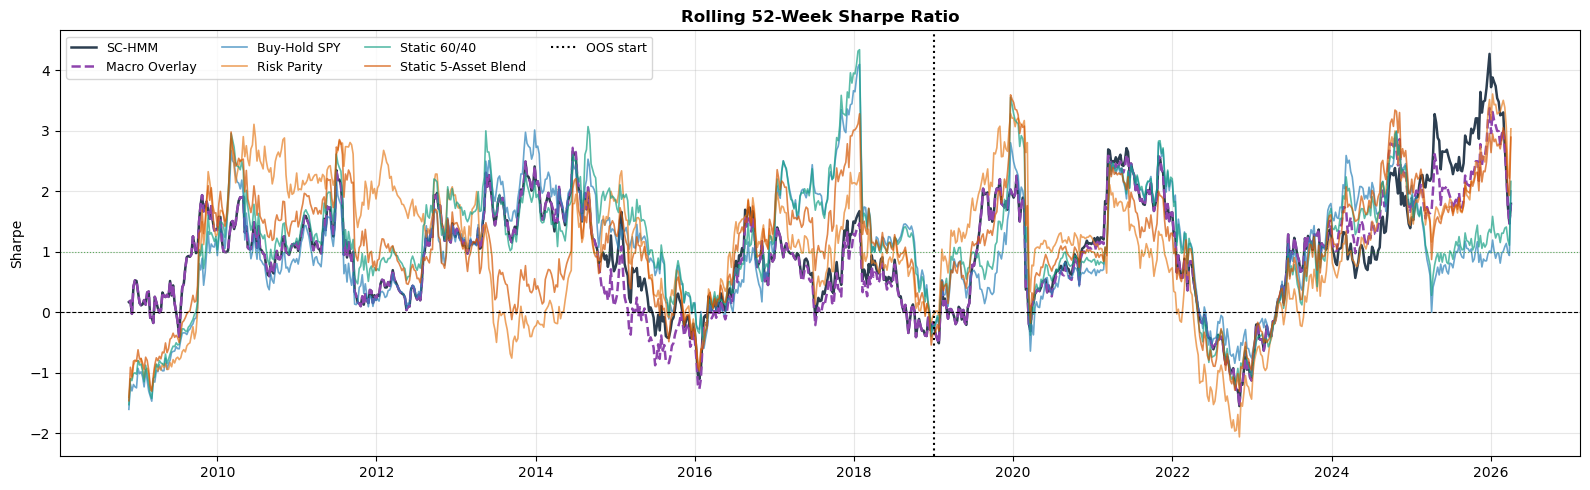

In [58]:
# ── Cell 16: Rolling 52-Week Sharpe Ratio ────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_bt, rolling_sharpe(ret_sm_hard),    color='#2c3e50', lw=1.8,
        label='SC-HMM')
ax.plot(dates_bt, rolling_sharpe(ret_sm_overlay), color='#8e44ad', lw=1.8, ls='--',
        label='Macro Overlay')
ax.plot(dates_bt, rolling_sharpe(bh_spy),         color='#2980b9', lw=1.2, alpha=0.7,
        label='Buy-Hold SPY')
ax.plot(dates_bt, rolling_sharpe(rp_ret),         color='#e67e22', lw=1.2, alpha=0.7,
        label='Risk Parity')
ax.plot(dates_bt, rolling_sharpe(static_6040),    color='#16a085', lw=1.2, alpha=0.7,
        label='Static 60/40')
ax.plot(dates_bt, rolling_sharpe(static_5a),      color='#d35400', lw=1.2, alpha=0.7,
        label='Static 5-Asset Blend')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(1, color='green', lw=0.8, ls=':', alpha=0.6)
ax.axvline(pd.Timestamp(TEST_START), color='black', ls=':', lw=1.5, label='OOS start')
ax.set_title('Rolling 52-Week Sharpe Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe')
ax.legend(fontsize=9, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


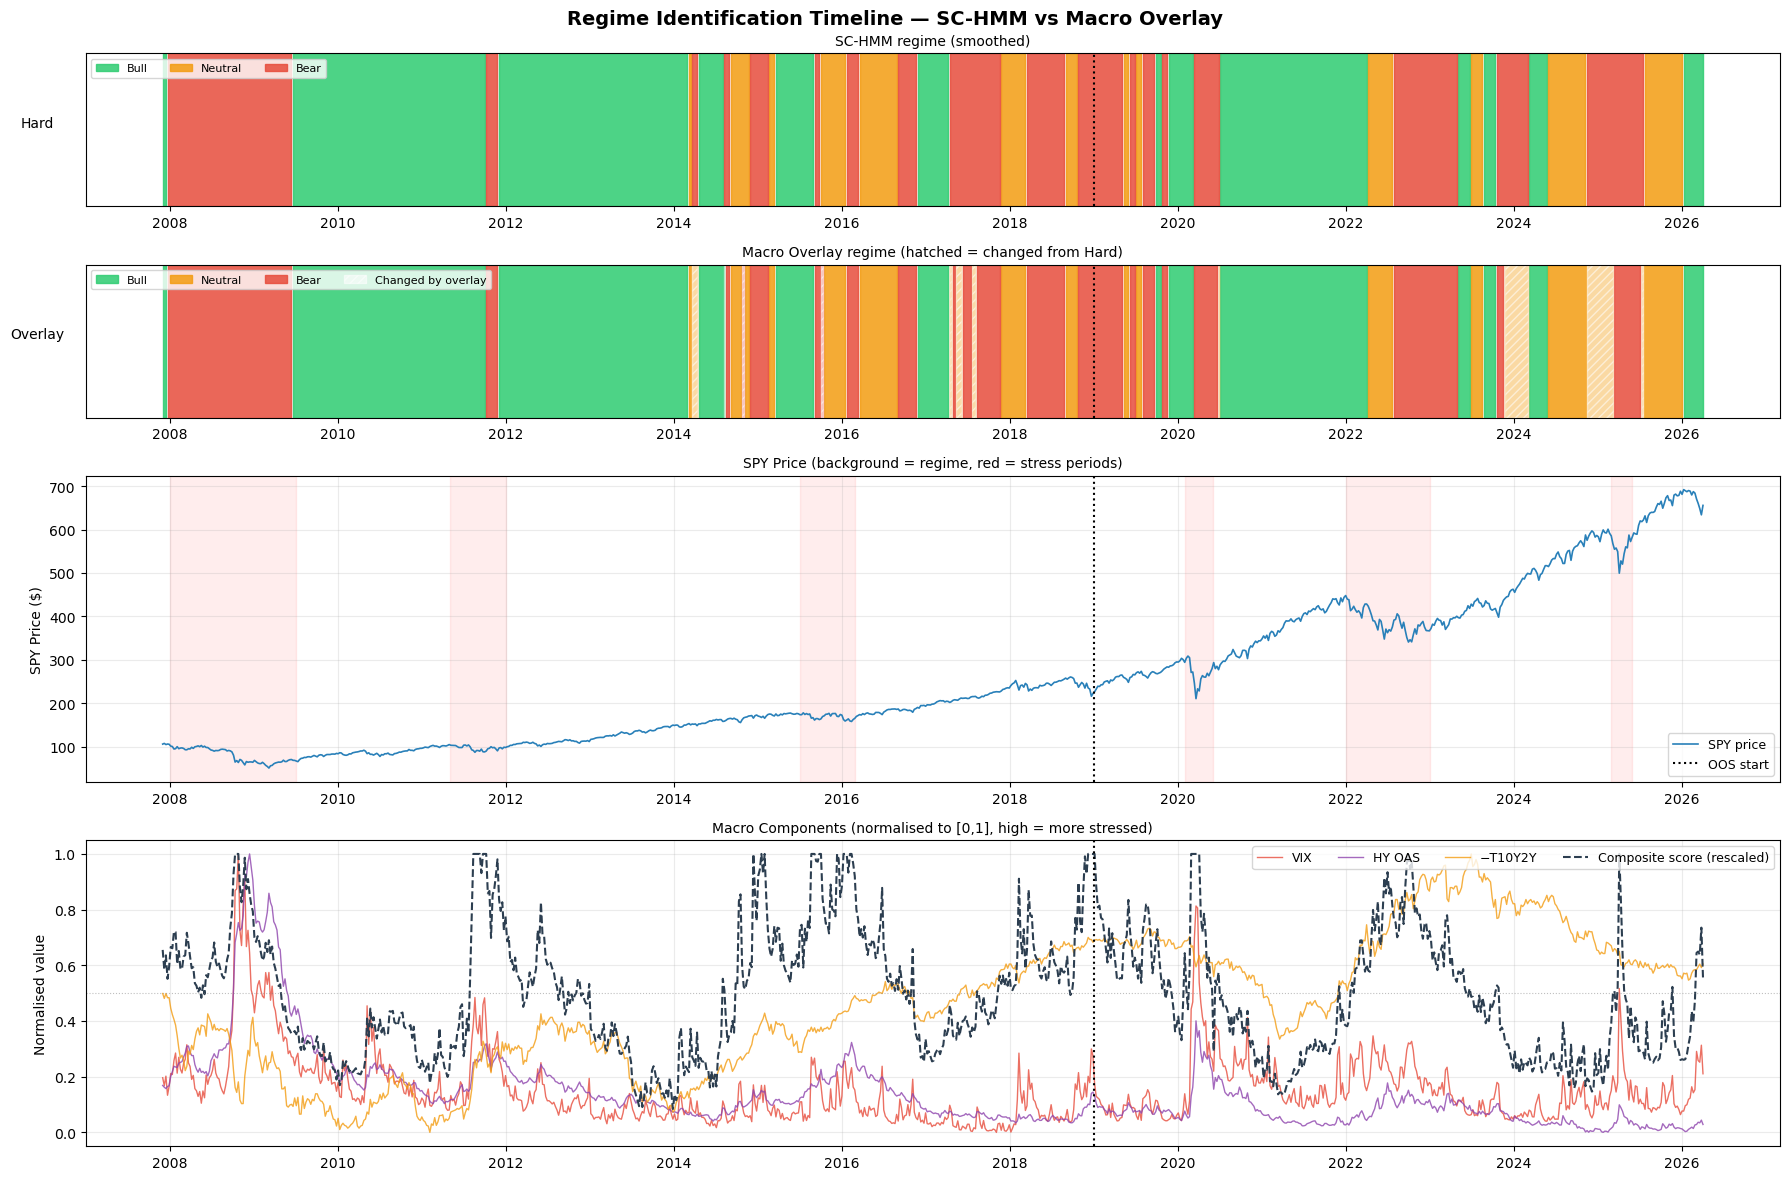

In [59]:
# ── Cell 17: Regime Identification Timeline ───────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(18, 12),
                         gridspec_kw={'height_ratios': [1, 1, 2, 2]})
fig.suptitle('Regime Identification Timeline — SC-HMM vs Macro Overlay',
             fontsize=14, fontweight='bold')

# Panel 1: SC-HMM regime band
ax = axes[0]
for reg in ALL_REGIMES:
    mask = reg_smooth == reg
    ax.fill_between(dates_bt, 0, 1, where=mask,
                    color=REGIME_COLORS[reg], alpha=0.85,
                    transform=ax.get_xaxis_transform(), label=reg.capitalize())
ax.axvline(pd.Timestamp(TEST_START), color='black', ls=':', lw=1.5)
ax.set_yticks([]); ax.set_ylabel('Hard', fontsize=10, rotation=0, labelpad=35)
ax.legend(loc='upper left', fontsize=8, ncol=3)
ax.set_title('SC-HMM regime (smoothed)', fontsize=10)

# Panel 2: Macro Overlay regime band
ax = axes[1]
for reg in ALL_REGIMES:
    mask = ov_reg_smooth == reg
    ax.fill_between(dates_bt, 0, 1, where=mask,
                    color=REGIME_COLORS[reg], alpha=0.85,
                    transform=ax.get_xaxis_transform(), label=reg.capitalize())
ax.axvline(pd.Timestamp(TEST_START), color='black', ls=':', lw=1.5)
diff_mask = reg_smooth != ov_reg_smooth
ax.fill_between(dates_bt, 0, 1, where=diff_mask, color='white', alpha=0.55, hatch='////',
                transform=ax.get_xaxis_transform(), label='Changed by overlay')
ax.set_yticks([]); ax.set_ylabel('Overlay', fontsize=10, rotation=0, labelpad=35)
ax.legend(loc='upper left', fontsize=8, ncol=4)
ax.set_title('Macro Overlay regime (hatched = changed from Hard)', fontsize=10)

# Panel 3: SPY price with regime shading
ax = axes[2]
spy_prices = prices['SPY'].reindex(dates_bt, method='ffill')
ax.plot(dates_bt, spy_prices, color='#2980b9', lw=1.2, label='SPY price')
for reg in ALL_REGIMES:
    mask = reg_smooth == reg
    ax.fill_between(dates_bt, spy_prices.min() * 0.9, spy_prices.max() * 1.05,
                    where=mask, color=REGIME_COLORS[reg], alpha=0.12,
                    transform=ax.get_xaxis_transform())
ax.axvline(pd.Timestamp(TEST_START), color='black', ls=':', lw=1.5, label='OOS start')
for _, (s, e) in STRESS_PERIODS.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.07, color='red')
ax.set_ylabel('SPY Price ($)')
ax.set_title('SPY Price (background = regime, red = stress periods)', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.25)

# Panel 4: Macro components (min-max normalised)
ax = axes[3]
macro_bt = macro.reindex(dates_bt, method='ffill')
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-10)
ax.plot(dates_bt, minmax(macro_bt['VIXCLS']),       color='#e74c3c', lw=1.0, alpha=0.8, label='VIX')
ax.plot(dates_bt, minmax(macro_bt['BAMLH0A0HYM2']), color='#8e44ad', lw=1.0, alpha=0.8, label='HY OAS')
ax.plot(dates_bt, minmax(-macro_bt['T10Y2Y']),      color='#f39c12', lw=1.0, alpha=0.8, label='−T10Y2Y')
ax.plot(dates_bt,
        macro_score_full.reindex(dates_bt, method='ffill').clip(-2, 2) / 4 + 0.5,
        color='#2c3e50', lw=1.5, ls='--', label='Composite score (rescaled)')
ax.axhline(0.5, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(pd.Timestamp(TEST_START), color='black', ls=':', lw=1.5)
ax.set_ylabel('Normalised value')
ax.set_title('Macro Components (normalised to [0,1], high = more stressed)', fontsize=10)
ax.legend(fontsize=9, ncol=4); ax.grid(alpha=0.25); ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


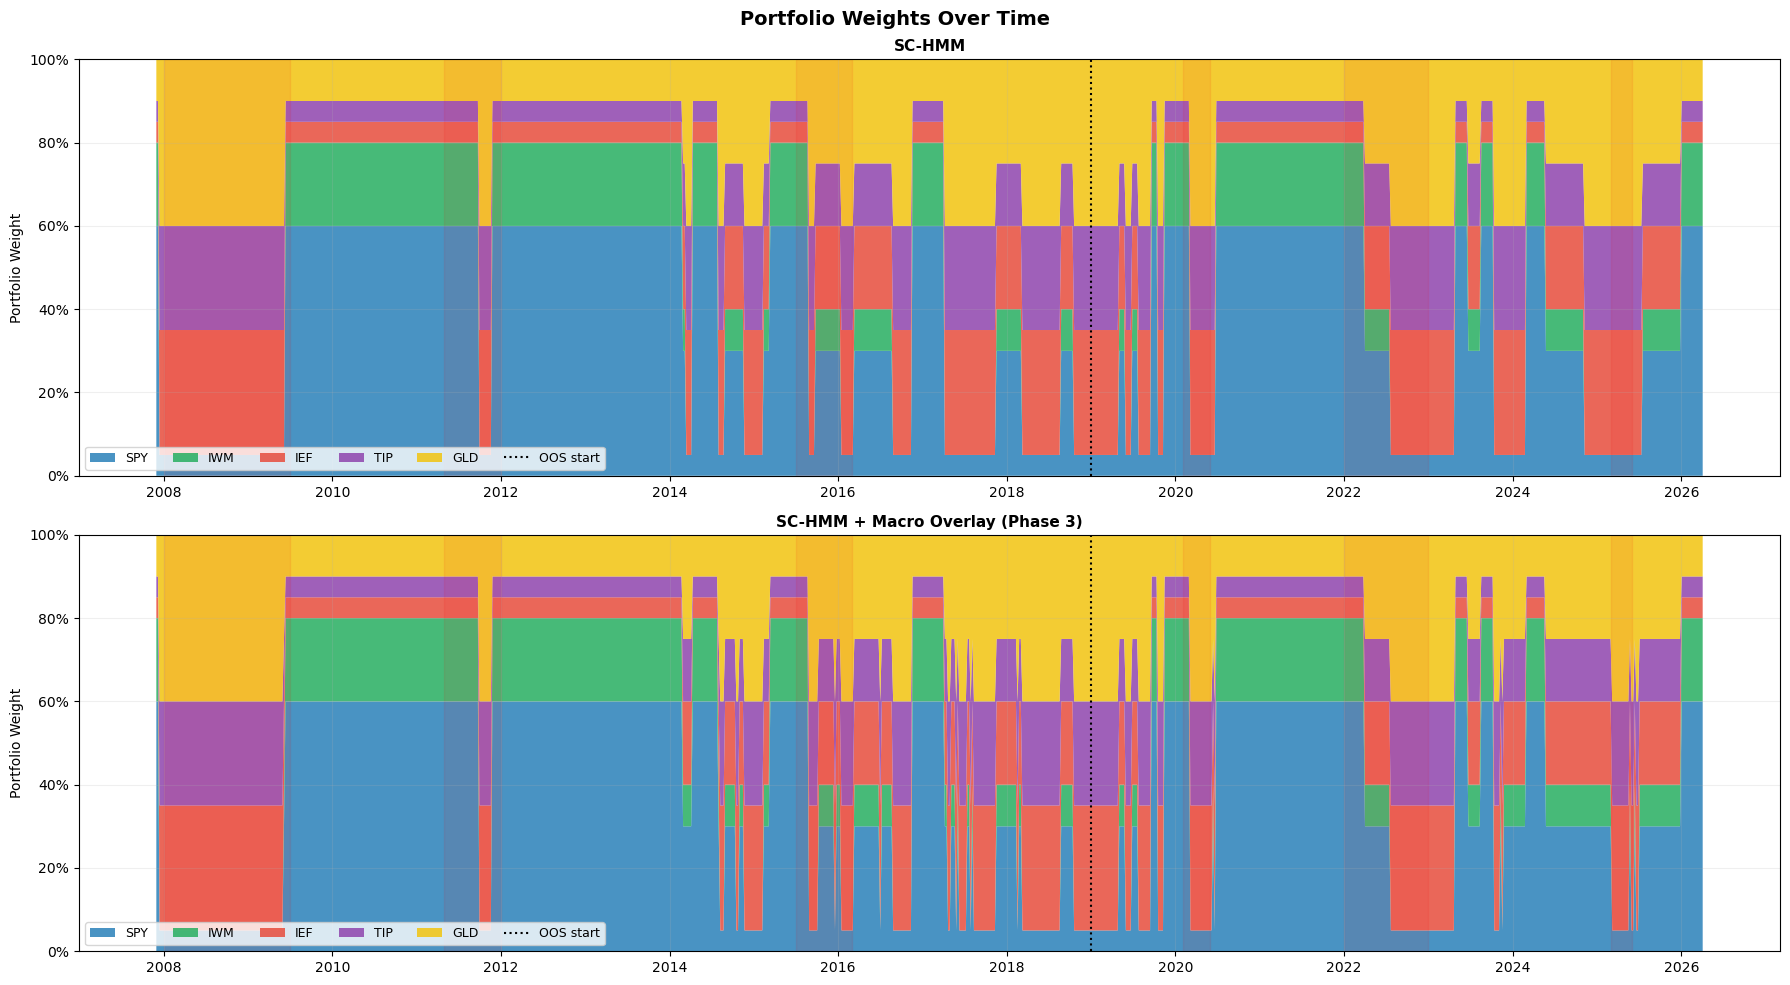

In [60]:
# ── Cell 18: Portfolio Weights Over Time ──────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Portfolio Weights Over Time', fontsize=14, fontweight='bold')
colors5       = ['#2980b9', '#27ae60', '#e74c3c', '#8e44ad', '#f1c40f']
w_hard_arr    = np.array(store['w_hard'])
w_overlay_arr = np.array(store['w_overlay'])

for ax, w_arr, title in zip(axes,
                             [w_hard_arr, w_overlay_arr],
                             ['SC-HMM', 'SC-HMM + Macro Overlay (Phase 3)']):
    ax.stackplot(dates_bt, *[w_arr[:, i] for i in range(N_ASSETS)],
                 labels=assets, colors=colors5, alpha=0.85)
    ax.axvline(pd.Timestamp(TEST_START), color='black', ls=':', lw=1.5, label='OOS start')
    for _, (s, e) in STRESS_PERIODS.items():
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Portfolio Weight')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(ncol=6, fontsize=9, loc='lower left')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


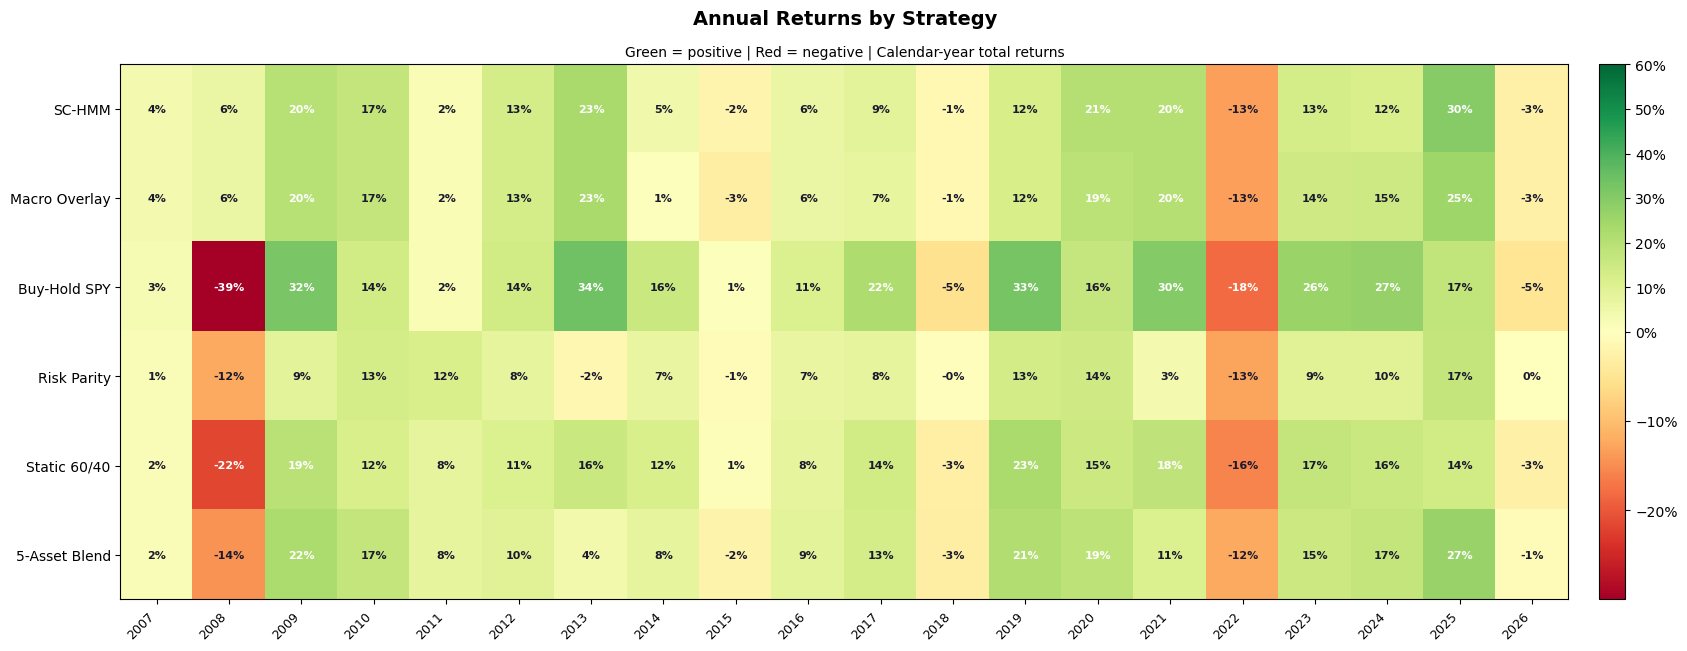

In [61]:
# ── Cell 19: Annual Returns Heatmap ───────────────────────────────────────

import matplotlib.colors as mcolors

strategies_annual = {
    'SC-HMM':     ret_sm_hard,
    'Macro Overlay':   ret_sm_overlay,
    'Buy-Hold SPY':    bh_spy,
    'Risk Parity':     rp_ret,
    'Static 60/40':    static_6040,
    '5-Asset Blend':   static_5a,
}

years    = sorted(dates_bt.year.unique())
ann_data = {}
for name, series in strategies_annual.items():
    ann_data[name] = {}
    for yr in years:
        mask = dates_bt.year == yr
        ann_data[name][yr] = np.nan if mask.sum() < 4 else np.cumprod(1 + series[mask])[-1] - 1

df_ann = pd.DataFrame(ann_data).T

fig, ax = plt.subplots(figsize=(max(14, len(years) * 0.85), len(strategies_annual) * 0.85 + 1.5))
fig.suptitle('Annual Returns by Strategy', fontsize=14, fontweight='bold')
cmap = mcolors.TwoSlopeNorm(vmin=-0.30, vcenter=0, vmax=0.60)
im   = ax.imshow(df_ann.values.astype(float), cmap='RdYlGn', norm=cmap, aspect='auto')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(df_ann.index)))
ax.set_yticklabels(df_ann.index, fontsize=10)
for i in range(len(df_ann.index)):
    for j in range(len(years)):
        val = df_ann.values[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 0.18 else '#1a1a2e'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=8, fontweight='bold', color=color)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02,
             format=mticker.PercentFormatter(1.0, decimals=0))
ax.set_title('Green = positive | Red = negative | Calendar-year total returns', fontsize=10)
plt.tight_layout()
plt.show()


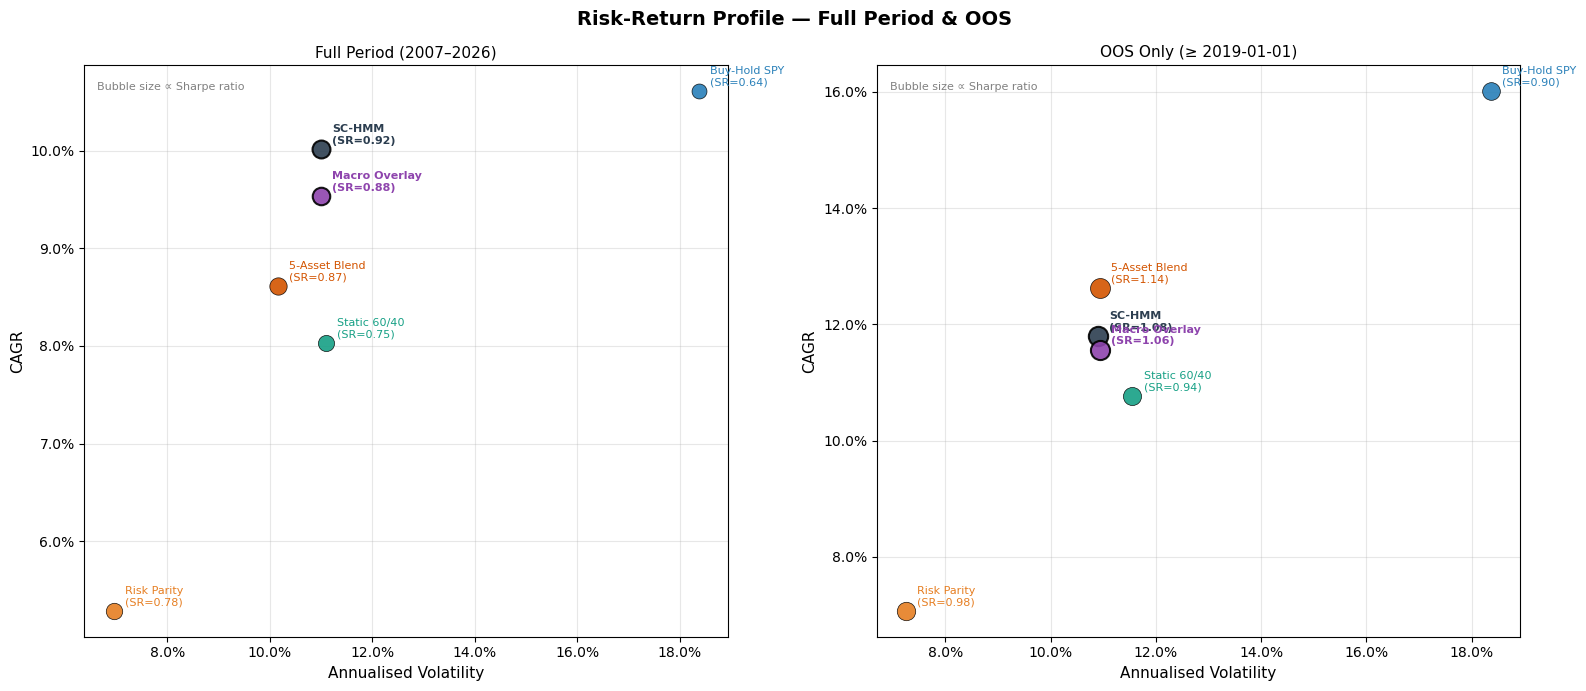

In [62]:
# ── Cell 20: Risk-Return Scatter ──────────────────────────────────────────

strategies_scatter = {
    'SC-HMM':    ret_sm_hard,
    'Macro Overlay':  ret_sm_overlay,
    'Buy-Hold SPY':   bh_spy,
    'Risk Parity':    rp_ret,
    'Static 60/40':   static_6040,
    '5-Asset Blend':  static_5a,
}
sc_colors = {
    'SC-HMM':   '#2c3e50',
    'Macro Overlay': '#8e44ad',
    'Buy-Hold SPY':  '#2980b9',
    'Risk Parity':   '#e67e22',
    'Static 60/40':  '#16a085',
    '5-Asset Blend': '#d35400',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Risk-Return Profile — Full Period & OOS', fontsize=14, fontweight='bold')

for ax, mask, period_label in zip(
        axes,
        [np.ones(len(dates_bt), dtype=bool), test_m],
        ['Full Period (2007–2026)', f'OOS Only (≥ {TEST_START})']):
    for name, series in strategies_scatter.items():
        r = series[mask]
        if len(r) < 10: continue
        vol      = r.std(ddof=1) * np.sqrt(ANNUALISE)
        cagr     = np.cumprod(1 + r)[-1] ** (ANNUALISE / len(r)) - 1
        sharpe   = (r.mean() * ANNUALISE) / vol if vol > 0 else 0
        is_model = name in ('SC-HMM', 'Macro Overlay')
        ax.scatter(vol, cagr, s=max(30, sharpe * 180), color=sc_colors[name],
                   edgecolors='black', linewidths=1.5 if is_model else 0.5,
                   zorder=5 if is_model else 3, alpha=0.9)
        ax.annotate(f'{name}\n(SR={sharpe:.2f})', (vol, cagr),
                    textcoords='offset points', xytext=(8, 4), fontsize=8,
                    color=sc_colors[name], fontweight='bold' if is_model else 'normal')
    ax.set_xlabel('Annualised Volatility', fontsize=11)
    ax.set_ylabel('CAGR', fontsize=11)
    ax.set_title(period_label, fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(alpha=0.3)
    ax.text(0.02, 0.97, 'Bubble size ∝ Sharpe ratio', transform=ax.transAxes,
            fontsize=8, va='top', color='gray')

plt.tight_layout()
plt.show()


In [63]:
# ── Cell 21: Final Summary ────────────────────────────────────────────────

ov_actions_final = Counter(store['overlay_action'])

print('\n' + '='*78)
print('  FINAL SUMMARY — SC-HMM PHASE 3: SPECTRAL + MACRO OVERLAY')
print('='*78)
print()
print('  Spectral backbone:')
print(f'  - K ∈ {{2,3}}, local eigengap criterion, {MAX_SPECTRAL_WINDOW}-week rolling window')
print(f'  - Self-tuning Gaussian kernel (Zelnik-Manor & Perona 2004)')
print(f'  - Dynamic K: K=2 dominant ({(K_arr==2).mean():.0%}), K=3 in {(K_arr==3).mean():.0%} of windows')
print()
print('  Macro overlay:')
print('  - Composite z-score = (VIX z + HY OAS z + inv(T10Y2Y) z) / 3')
print(f'  - Bear + macro benign (composite < −{MACRO_NEUTRAL_THRESH}): DOWNGRADE bear → neutral')
print(f'    Triggered {ov_actions_final["downgraded"]} times ({ov_actions_final["downgraded"]/len(dates_bt):.1%} of weeks)')
print(f'  - Neutral + extreme VIX (z > {MACRO_EXTREME_THRESH}): UPGRADE neutral → bear')
print(f'    Triggered {ov_actions_final["upgraded"]} times ({ov_actions_final["upgraded"]/len(dates_bt):.1%} of weeks)')
print('  - Bull regime: always passed through unchanged')
print()

rows = []
for series, name in STRATEGY_SERIES:
    row = {'Strategy': name}
    row.update(compute_metrics(series))
    rows.append(row)
print(pd.DataFrame(rows).set_index('Strategy').to_string())

print()
print('  Known limitations:')
print('  - Allocation weights were set with full-sample awareness → hyperparameter')
print('    selection bias inherent to all regime-based backtests.')
print('  - Macro thresholds calibrated on the training set → minor data snooping.')
print('  - 2022 rate-hike regime: equity-duration correlation inverted; spectral')
print('    clustering partially mis-classified the regime (bonds and equities fell')
print('    together, removing the usual flight-to-quality signal). TIP\'s lower')
print('    duration sensitivity partially mitigated this drawdown vs the TLT variant.')
print('  - Bear cluster mean SPY may remain positive due to high-vol recovery weeks.')
print('    This is structurally correct; the macro overlay addresses the consequence.')



  FINAL SUMMARY — SC-HMM PHASE 3: SPECTRAL + MACRO OVERLAY

  Spectral backbone:
  - K ∈ {2,3}, local eigengap criterion, 260-week rolling window
  - Self-tuning Gaussian kernel (Zelnik-Manor & Perona 2004)
  - Dynamic K: K=2 dominant (59%), K=3 in 41% of windows

  Macro overlay:
  - Composite z-score = (VIX z + HY OAS z + inv(T10Y2Y) z) / 3
  - Bear + macro benign (composite < −0.5): DOWNGRADE bear → neutral
    Triggered 52 times (5.4% of weeks)
  - Neutral + extreme VIX (z > 2.0): UPGRADE neutral → bear
    Triggered 7 times (0.7% of weeks)
  - Bull regime: always passed through unchanged

                         Cumul.Ret    CAGR Ann.Vol Sharpe Sortino   Max DD Calmar Hit Rate
Strategy                                                                                  
* SC-HMM                    480.1%  10.01%  11.00%   0.92    1.28  -18.35%   0.55    57.0%
* SC-HMM + Macro Overlay    435.2%   9.53%  11.00%   0.88    1.23  -18.35%   0.52    56.6%
  Buy-Hold SPY              540.6%